1. Input Data

In [1]:
import numpy as np
import torch

data = np.load("frozen_soil_sensor_dataset_test_corrected.npz")

# 完整温度场：(n_case, Nt, Nz)
all_T_full = data["all_T"]

# 原始11个传感器温度：(n_case, Nt, n_sensor)
all_T_sensor_clean = data["all_T_sensor"]

params_arr = data["params_arr"]
curve_ids = data["curve_ids"]
t = data["t"]

# 完整空间网格和原始传感器深度
z_grid = data["z"]
sensor_z = data["sensor_z"]

# (n_case, Nt, n_sensor) -> (n_case, n_sensor, Nt)
X_sensor_clean = torch.from_numpy(
    all_T_sensor_clean
).permute(0, 2, 1).float()

print("all_T_full        :", all_T_full.shape)
print("all_T_sensor_clean:", all_T_sensor_clean.shape)
print("X_sensor_clean    :", X_sensor_clean.shape)
print("z_grid            :", z_grid.shape)
print("sensor_z          :", sensor_z)
print("params_arr        :", params_arr.shape)

all_T_full        : (220, 61, 49)
all_T_sensor_clean: (220, 61, 11)
X_sensor_clean    : torch.Size([220, 11, 61])
z_grid            : (49,)
sensor_z          : [0.05 0.1  0.15 0.2  0.25 0.3  0.35 0.4  0.45 0.5  0.55]
params_arr        : (220, 6)


2. 建立 Inverse DeepONet

2.1. 网络架构

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F


class BranchCNN(nn.Module):
    
    def __init__(self, n_sensors: int, latent_dim: int = 64):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv1d(n_sensors, 16, kernel_size=5, padding=2),
            nn.ReLU(),
            nn.Conv1d(16, 32, kernel_size=5, padding=2),
            nn.ReLU(),
        )
        # 对时间维做全局平均池化 -> (B, 32)
        self.pool = nn.AdaptiveAvgPool1d(1)  # 捕捉温度平均值
        self.ln   = nn.LayerNorm(32)
        self.fc   = nn.Linear(32, latent_dim)

    def forward(self, x):
        # x: (B, n_sensors, Nt)
        h = self.conv(x)              # (B, 32, Nt)
        h = self.pool(h).squeeze(-1)  # (B, 32)
        h = self.ln(h)
        b = self.fc(h)                # (B, latent_dim = p)
        return b


class TrunkNet(nn.Module):
    
    def __init__(self, latent_dim: int = 64, hidden: int = 64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, hidden),
            nn.Tanh(),
            nn.Linear(hidden, hidden),
            nn.Tanh(),
            nn.Linear(hidden, latent_dim)
        )

    def forward(self, T_query):          # T_query 必须是顺序向量
        # 确保是 1D tensor
        if T_query.dim() == 1:
            x = T_query.unsqueeze(-1)    # (n_T, 1)
        else:
            # 如果是 (B, n_T)，也兼容
            x = T_query.unsqueeze(-1)
        t = self.net(x)                  # (..., latent_dim)
        return t


class InverseDeepONetMonotone(nn.Module):
    
    def __init__(self,
                 n_sensors: int,
                 latent_dim: int = 64,
                 theta_sat: float = 0.5):
        super().__init__()
        self.branch     = BranchCNN(n_sensors, latent_dim)
        self.trunk      = TrunkNet(latent_dim)
        self.theta_sat  = theta_sat
        self.latent_dim = latent_dim

        # 由 branch 的隐向量预测每个样本的残余含水量系数 (0~1)
        self.fc_res = nn.Linear(latent_dim, 1)

        # 增加一个“陡峭度/尺度”自由度（每个样本 1 个标量）
        self.fc_scale = nn.Linear(latent_dim, 1)

    def forward(self, X_sensor, T_query):
        
        device = X_sensor.device
        T_query = T_query.to(device)

        B   = X_sensor.size(0)
        n_T = T_query.numel()

        # -------- 1. 分离 T<0 和 T>=0 --------
        mask_neg = (T_query < 0)          # (n_T,)
        mask_pos = ~mask_neg              # (n_T,)

        idx_neg = torch.nonzero(mask_neg, as_tuple=False).squeeze(-1)  # (n_T_neg,)
        idx_pos = torch.nonzero(mask_pos, as_tuple=False).squeeze(-1)  # (n_T_pos,)

        T_neg = T_query[idx_neg]          # (n_T_neg,)

        # -------- 2. branch: 传感器时序 -> b(u), 再得到 θ_res --------
        # b: (B, latent_dim)
        b = self.branch(X_sensor)         # (B, latent_dim)

        # 每个样本的残余含水量 θ_res ∈ (0, theta_sat)
        # 先映射到 (0,1)，再乘以 theta_sat
        theta_res_frac = torch.sigmoid(self.fc_res(b))   # (B, 1), 0~1
        theta_res = theta_res_frac * self.theta_sat      # (B, 1)

        # -------- 3. trunk: T<0 -> t(T) --------
        t_neg = self.trunk(T_neg)         # (n_T_neg, latent_dim)

        # -------- 4. DeepONet 组合得到一个单调的 0~1 形状函数 s(T) --------
        # raw: (B, n_T_neg)
        theta_raw_neg = torch.matmul(b, t_neg.T)   # (B, n_T_neg)

        # softplus 确保增量非负
        scale = 0.2 + 5.0 * torch.sigmoid(self.fc_scale(b))   # (B,1) > 0
        delta = F.softplus(theta_raw_neg) * scale              # (B,n_T_neg)

        # 沿 T 维累积和 -> 严格单调非减
        theta_cum = torch.cumsum(delta, dim=1)     # (B, n_T_neg)

        eps = 1e-6
        # 归一化到 [0,1]，最后一点 = 1
        s_neg = theta_cum / (theta_cum[:, -1:].clone() + eps)   # (B, n_T_neg), 0~1

        # -------- 5. 映射到 [θ_res, θ_sat] --------
        theta_neg = theta_res + (self.theta_sat - theta_res) * s_neg  # (B, n_T_neg)

        # -------- 6. 组装完整 θ(T) --------
        theta = torch.zeros(B, n_T, device=device)

        if idx_neg.numel() > 0:
            theta[:, idx_neg] = theta_neg

        if idx_pos.numel() > 0:
            theta[:, idx_pos] = self.theta_sat

        return theta

4. 加载 DeepONet

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

n_case, n_sensors, Nt = X_sensor_clean.shape
latent_dim = 8
theta_sat = 0.5

deeponet_eval = InverseDeepONetMonotone(
    n_sensors=n_sensors,
    latent_dim=latent_dim,
    theta_sat=theta_sat,
).to(device)

state_dict = torch.load(
    "deeponet_sfcc_operator_train_80.pt",
    map_location=device
)

deeponet_eval.load_state_dict(state_dict)
deeponet_eval.eval()

print("Loaded Train80 SC-DION model.")

Using device: cuda
Loaded Train80 SC-DION model.


5. Robustness to changes in sensor depths

5.1 Reference SFCCs

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

theta_sat = 0.5  # 之前统一的饱和体积含水量

param_cols = ["form_id", "alpha", "beta", "theta_res", "gamma", "n"]
params_df = pd.DataFrame(params_arr, columns=param_cols)
params_df["curve_id"] = curve_ids
print(params_df.head())


   form_id  alpha  beta  theta_res     gamma    n  curve_id
0      2.0    0.0   0.0   0.099743  1.430308  0.0         1
1      2.0    0.0   0.0   0.101682  0.833243  0.0         2
2      2.0    0.0   0.0   0.098324  0.501503  0.0         3
3      2.0    0.0   0.0   0.176258  0.801955  0.0         4
4      2.0    0.0   0.0   0.172534  0.616955  0.0         5


In [ ]:
def theta_power_law(T, alpha, beta, theta_sat=0.5):
    T = np.asarray(T, dtype=float)
    x = np.maximum(-T, 1e-6)
    val = alpha * x**beta
    return np.clip(val, 0.0, theta_sat)

# θ = θ_res + (θ_sat - θ_res) * exp(-((T - T0)/γ)^2)
def theta_exponential(T, theta_res, gamma, theta_sat=0.5, T0=0.0):
    T = np.asarray(T, dtype=float)
    val = theta_res + (theta_sat - theta_res) * np.exp(-((T - T0) / gamma)**2)
    return np.clip(val, 0.0, theta_sat)

# VG
def theta_vg(T, theta_res, alpha, n, theta_sat=0.5):
    T = np.asarray(T, dtype=float)
    x = np.maximum(-T, 1e-6)   # 防止 0
    m = 1.0 - 1.0 / n
    val = theta_res + (theta_sat - theta_res) * (1.0 + (alpha * x)**n)**(-m)
    return np.clip(val, 0.0, theta_sat)

# 统一接口
def theta_w(T, param_row, theta_sat=0.5):
    
    form = int(param_row["form_id"])  # 1, 2, or 3

    if form == 1:
        return theta_power_law(
            T,
            param_row["alpha"],
            param_row["beta"],
            theta_sat=theta_sat,
        )

    elif form == 2:
        return theta_exponential(
            T,
            param_row["theta_res"],
            param_row["gamma"],
            theta_sat=theta_sat,
            T0 = 0.0
        )

    elif form == 3:
        return theta_vg(
            T,
            param_row["theta_res"],
            param_row["alpha"],
            param_row["n"],
            theta_sat=theta_sat
        )
        
    else:
        raise ValueError(f"未知 form_id={form}，期望是 1/2/3")


In [6]:
# 评估用温度网格（和训练范围一致即可）
T_eval_np = np.linspace(-15.0, 0.0, 50).astype("float32")
n_T_eval = T_eval_np.shape[0]
n_case = params_arr.shape[0]

theta_true_np = np.zeros((n_case, n_T_eval), dtype=np.float32)

for i in range(n_case):
    row = params_df.iloc[i]
    theta_true_np[i] = theta_w(T_eval_np, row, theta_sat=theta_sat)

print("theta_true_np shape:", theta_true_np.shape)   # (n_case, 50)


theta_true_np shape: (220, 50)


5.2 SFCC inversion with shifted sensor depths

In [7]:
import numpy as np
import pandas as pd
import torch


def extract_temperature_at_depths(
    temperature_field,
    spatial_grid,
    target_depths
):
    """
    从完整温度场中线性插值得到指定深度处的温度时序。

    Parameters
    ----------
    temperature_field : ndarray
        Shape: (n_case, Nt, Nz)

    spatial_grid : ndarray
        Shape: (Nz,)

    target_depths : ndarray
        Shape: (n_sensor,)

    Returns
    -------
    temperature_sensor : ndarray
        Shape: (n_case, Nt, n_sensor)
    """

    temperature_field = np.asarray(
        temperature_field,
        dtype=np.float64
    )

    spatial_grid = np.asarray(
        spatial_grid,
        dtype=np.float64
    )

    target_depths = np.asarray(
        target_depths,
        dtype=np.float64
    )

    if np.any(target_depths < spatial_grid[0]):
        raise ValueError("A shifted sensor is above the spatial domain.")

    if np.any(target_depths > spatial_grid[-1]):
        raise ValueError("A shifted sensor is below the spatial domain.")

    # 每个目标深度右侧的空间网格编号
    right_idx = np.searchsorted(
        spatial_grid,
        target_depths,
        side="right"
    )

    right_idx = np.clip(
        right_idx,
        1,
        len(spatial_grid) - 1
    )

    left_idx = right_idx - 1

    z_left = spatial_grid[left_idx]
    z_right = spatial_grid[right_idx]

    weight = (
        (target_depths - z_left)
        / (z_right - z_left)
    )

    # Shape: (n_case, Nt, n_sensor)
    temperature_sensor = (
        (1.0 - weight)[None, None, :]
        * temperature_field[:, :, left_idx]
        +
        weight[None, None, :]
        * temperature_field[:, :, right_idx]
    )

    return temperature_sensor.astype(np.float32)

In [8]:
sensor_z_np = np.asarray(
    sensor_z,
    dtype=np.float64
)

z_grid_np = np.asarray(
    z_grid,
    dtype=np.float64
)

# 从完整温度场重新提取原始传感器位置的温度
all_T_sensor_nominal = extract_temperature_at_depths(
    temperature_field=all_T_full,
    spatial_grid=z_grid_np,
    target_depths=sensor_z_np
)

# 应当接近0，因为原始传感器位置正好位于空间网格上
max_interpolation_difference = np.max(
    np.abs(
        all_T_sensor_nominal
        - all_T_sensor_clean
    )
)

print(
    "Maximum difference at nominal sensor depths:",
    max_interpolation_difference
)

Maximum difference at nominal sensor depths: 4.768324615156416e-07


In [9]:
# =========================================================
# Robustness test for changes in sensor depths
# =========================================================

T_eval = torch.from_numpy(
    T_eval_np
).float().to(device)

n_case, Nt, n_sensors = all_T_sensor_clean.shape

# 最大绝对深度变化，单位为 m
depth_shift_levels = np.array(
    [0.000, 0.005, 0.010, 0.015, 0.020],
    dtype=np.float64
)

# 每个非零深度变化水平测试20组配置
n_repeats = 20

# 固定随机种子，保证结果可复现
rng = np.random.default_rng(2026)

# 每个元素位于[-1, 1]
# 同一组随机模式在不同深度变化水平下只改变幅度
normalized_depth_patterns = rng.uniform(
    low=-1.0,
    high=1.0,
    size=(n_repeats, n_sensors)
)

# Global R2使用固定的reference分母
ss_tot_global = np.sum(
    (
        theta_true_np
        - np.mean(theta_true_np)
    )**2
)

depth_shift_results = {}

deeponet_eval.eval()

for max_shift in depth_shift_levels:

    # 无深度变化只需要计算一次
    if np.isclose(max_shift, 0.0):
        repeat_ids = [0]
    else:
        repeat_ids = range(n_repeats)

    rmse_values = []
    r2_values = []
    shifted_depth_configurations = []

    print(
        f"\nMaximum sensor-depth change: "
        f"{max_shift:.3f} m"
    )

    for repeat_id in repeat_ids:

        if np.isclose(max_shift, 0.0):

            shifted_sensor_z = sensor_z_np.copy()

        else:

            depth_offsets = (
                max_shift
                * normalized_depth_patterns[repeat_id]
            )

            shifted_sensor_z = (
                sensor_z_np
                + depth_offsets
            )

        # 检查所有传感器仍位于空间计算域内
        if shifted_sensor_z.min() < z_grid_np.min():
            raise ValueError("Shifted sensor is outside the domain.")

        if shifted_sensor_z.max() > z_grid_np.max():
            raise ValueError("Shifted sensor is outside the domain.")

        # 检查传感器顺序没有发生交叉
        if np.any(np.diff(shifted_sensor_z) <= 0.0):
            raise ValueError(
                "Shifted sensor depths are not strictly ordered."
            )

        # 1. 从完整温度场提取新深度处的温度时序
        all_T_sensor_shifted = extract_temperature_at_depths(
            temperature_field=all_T_full,
            spatial_grid=z_grid_np,
            target_depths=shifted_sensor_z
        )

        # 2. 转换成网络要求的格式
        # (n_case, Nt, n_sensor)
        # -> (n_case, n_sensor, Nt)
        X_sensor_shifted = torch.from_numpy(
            all_T_sensor_shifted
        ).permute(0, 2, 1).float().to(device)

        # 3. 使用训练好的Train80模型直接推理
        with torch.no_grad():

            theta_pred = deeponet_eval(
                X_sensor_shifted,
                T_eval
            )

        theta_pred_np = (
            theta_pred
            .cpu()
            .numpy()
        )

        # 4. 计算Global SFCC RMSE和R2
        err_global = (
            theta_pred_np
            - theta_true_np
        )

        global_rmse = np.sqrt(
            np.mean(err_global**2)
        )

        ss_res_global = np.sum(
            err_global**2
        )

        global_r2 = (
            1.0
            - ss_res_global / ss_tot_global
        )

        rmse_values.append(global_rmse)
        r2_values.append(global_r2)

        shifted_depth_configurations.append(
            shifted_sensor_z.copy()
        )

    depth_shift_results[max_shift] = {
        "rmse": np.asarray(
            rmse_values,
            dtype=np.float64
        ),
        "r2": np.asarray(
            r2_values,
            dtype=np.float64
        ),
        "sensor_depths": np.asarray(
            shifted_depth_configurations,
            dtype=np.float64
        )
    }

print("\nSensor-depth robustness test completed.")


Maximum sensor-depth change: 0.000 m

Maximum sensor-depth change: 0.005 m

Maximum sensor-depth change: 0.010 m

Maximum sensor-depth change: 0.015 m

Maximum sensor-depth change: 0.020 m

Sensor-depth robustness test completed.


In [10]:
summary_rows = []

for max_shift in depth_shift_levels:

    result = depth_shift_results[max_shift]

    rmse_values = result["rmse"]
    r2_values = result["r2"]

    if len(rmse_values) > 1:

        rmse_std = rmse_values.std(ddof=1)
        r2_std = r2_values.std(ddof=1)

    else:

        rmse_std = 0.0
        r2_std = 0.0

    summary_rows.append({
        "Maximum depth change (m)": max_shift,
        "Maximum depth change (cm)": max_shift * 100.0,
        "Number of configurations": len(rmse_values),
        "Global RMSE mean": rmse_values.mean(),
        "Global RMSE std": rmse_std,
        "Global R2 mean": r2_values.mean(),
        "Global R2 std": r2_std,
        "Global RMSE max": rmse_values.max(),
        "Global R2 min": r2_values.min()
    })

depth_shift_summary = pd.DataFrame(
    summary_rows
)

display(depth_shift_summary)

,Maximum depth change (m),Maximum depth change (cm),Number of configurations,Global RMSE mean,Global RMSE std,Global R2 mean,Global R2 std,Global RMSE max,Global R2 min
0,0.000,0.0,1,0.032020,0.000000,0.908524,0.000000,0.032020,0.908524
1,0.005,0.5,20,0.032446,0.001319,0.905924,0.007840,0.036528,0.880953
2,0.010,1.0,20,0.034025,0.002895,0.895999,0.018840,0.043596,0.830422
3,0.015,1.5,20,0.036505,0.005132,0.878867,0.037217,0.052077,0.758028
4,0.020,2.0,20,0.039619,0.007761,0.854847,0.063049,0.060629,0.672024


In [11]:
for max_shift in depth_shift_levels[1:]:

    result = depth_shift_results[max_shift]

    worst_id = int(
        np.argmax(result["rmse"])
    )

    worst_sensor_depths = (
        result["sensor_depths"][worst_id]
    )

    depth_offsets = (
        worst_sensor_depths
        - sensor_z_np
    )

    print(
        f"\nMaximum change = {max_shift * 100:.1f} cm"
    )

    print(
        "Worst depth offsets (cm):",
        np.round(depth_offsets * 100.0, 3)
    )

    print(
        f"Global RMSE = "
        f"{result['rmse'][worst_id]:.6f}"
    )

    print(
        f"Global R2 = "
        f"{result['r2'][worst_id]:.6f}"
    )


Maximum change = 0.5 cm
Worst depth offsets (cm): [ 0.245  0.389 -0.284  0.15   0.217  0.342 -0.156  0.189  0.104 -0.091
 -0.398]
Global RMSE = 0.036528
Global R2 = 0.880953

Maximum change = 1.0 cm
Worst depth offsets (cm): [ 0.49   0.779 -0.568  0.3    0.435  0.684 -0.312  0.378  0.209 -0.181
 -0.797]
Global RMSE = 0.043596
Global R2 = 0.830422

Maximum change = 1.5 cm
Worst depth offsets (cm): [ 0.735  1.168 -0.853  0.45   0.652  1.027 -0.469  0.566  0.313 -0.272
 -1.195]
Global RMSE = 0.052077
Global R2 = 0.758028

Maximum change = 2.0 cm
Worst depth offsets (cm): [ 0.98   1.558 -1.137  0.601  0.87   1.369 -0.625  0.755  0.418 -0.363
 -1.593]
Global RMSE = 0.060629
Global R2 = 0.672024


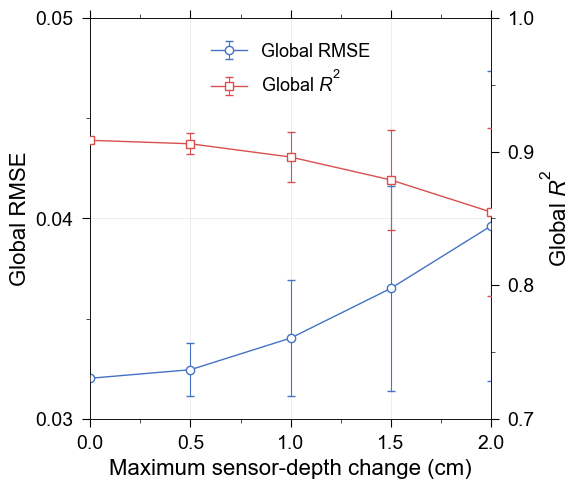

In [12]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.ticker import MultipleLocator, FormatStrFormatter


# =========================================================
# 1. 可调参数
# =========================================================

FIG_SIZE = 6.0

FONT_FAMILY = "Arial"
FONT_SIZE = 14
LABEL_SIZE = 16
TICK_SIZE = 14
LEGEND_SIZE = 13

LINE_WIDTH = 1.0
MARKER_SIZE = 6.0
MARKER_EDGE_WIDTH = 1.0

ERROR_LINE_WIDTH = 0.8
CAP_SIZE = 3.0

SPINE_WIDTH = 0.5

MAJOR_TICK_LENGTH = 6
MAJOR_TICK_WIDTH = 0.8

MINOR_TICK_LENGTH = 3
MINOR_TICK_WIDTH = 0.5

# 与噪声图一致
RMSE_COLOR = "#4472C4"
R2_COLOR = "#D94F4F"


# =========================================================
# 2. 坐标轴范围
# =========================================================

# x轴：最大传感器深度变化，单位cm
X_MIN = 0.0
X_MAX = 2.0
X_MAJOR_STEP = 0.5
X_MINOR_STEP = 0.25

# 左侧RMSE轴
RMSE_Y_MIN = 0.03
RMSE_Y_MAX = 0.05
RMSE_MAJOR_STEP = 0.01
RMSE_MINOR_STEP = 0.005

# 右侧R2轴
R2_Y_MIN = 0.7
R2_Y_MAX = 1.0
R2_MAJOR_STEP = 0.1
R2_MINOR_STEP = 0.05


# =========================================================
# 3. 字体
# =========================================================

mpl.rcParams["font.family"] = FONT_FAMILY
mpl.rcParams["font.size"] = FONT_SIZE
mpl.rcParams["axes.labelsize"] = LABEL_SIZE
mpl.rcParams["xtick.labelsize"] = TICK_SIZE
mpl.rcParams["ytick.labelsize"] = TICK_SIZE
mpl.rcParams["legend.fontsize"] = LEGEND_SIZE

mpl.rcParams["mathtext.fontset"] = "custom"
mpl.rcParams["mathtext.rm"] = "Arial"
mpl.rcParams["mathtext.it"] = "Arial:italic"
mpl.rcParams["mathtext.bf"] = "Arial:bold"


# =========================================================
# 4. 从汇总表读取统计结果
# =========================================================

depth_change_cm = depth_shift_summary[
    "Maximum depth change (cm)"
].to_numpy(dtype=float)

rmse_mean = depth_shift_summary[
    "Global RMSE mean"
].to_numpy(dtype=float)

rmse_std = depth_shift_summary[
    "Global RMSE std"
].to_numpy(dtype=float)

r2_mean = depth_shift_summary[
    "Global R2 mean"
].to_numpy(dtype=float)

r2_std = depth_shift_summary[
    "Global R2 std"
].to_numpy(dtype=float)


# =========================================================
# 5. 正方形图幅和双纵坐标
# =========================================================

fig, ax_rmse = plt.subplots(
    figsize=(FIG_SIZE, FIG_SIZE)
)

ax_r2 = ax_rmse.twinx()

# 正方形绘图区
ax_rmse.set_box_aspect(1)

# 网格线位于数据下方
ax_rmse.set_axisbelow(True)


# =========================================================
# 6. Global SFCC RMSE
# =========================================================

rmse_plot = ax_rmse.errorbar(
    depth_change_cm,
    rmse_mean,
    yerr=rmse_std,
    color=RMSE_COLOR,
    linewidth=LINE_WIDTH,
    marker="o",
    markerfacecolor="white",
    markeredgecolor=RMSE_COLOR,
    markeredgewidth=MARKER_EDGE_WIDTH,
    markersize=MARKER_SIZE,
    elinewidth=ERROR_LINE_WIDTH,
    capsize=CAP_SIZE,
    capthick=ERROR_LINE_WIDTH,
    label="Global SFCC RMSE",
    zorder=3
)


# =========================================================
# 7. Global SFCC R2
# =========================================================

r2_plot = ax_r2.errorbar(
    depth_change_cm,
    r2_mean,
    yerr=r2_std,
    color=R2_COLOR,
    linewidth=LINE_WIDTH,
    marker="s",
    markerfacecolor="white",
    markeredgecolor=R2_COLOR,
    markeredgewidth=MARKER_EDGE_WIDTH,
    markersize=MARKER_SIZE,
    elinewidth=ERROR_LINE_WIDTH,
    capsize=CAP_SIZE,
    capthick=ERROR_LINE_WIDTH,
    label=r"Global SFCC $R^2$",
    zorder=3
)


# =========================================================
# 8. 坐标轴标题
# =========================================================

ax_rmse.set_xlabel(
    "Maximum sensor-depth change (cm)",
    color="black"
)

ax_rmse.set_ylabel(
    "Global RMSE",
    color="black"
)

ax_r2.set_ylabel(
    r"Global $R^2$",
    color="black"
)


# =========================================================
# 9. 坐标范围
# =========================================================

ax_rmse.set_xlim(X_MIN, X_MAX)
ax_rmse.set_ylim(RMSE_Y_MIN, RMSE_Y_MAX)
ax_r2.set_ylim(R2_Y_MIN, R2_Y_MAX)


# =========================================================
# 10. 主、次刻度
# =========================================================

# x轴
ax_rmse.set_xticks(
    np.arange(
        X_MIN,
        X_MAX + X_MAJOR_STEP / 2,
        X_MAJOR_STEP
    )
)

ax_rmse.xaxis.set_minor_locator(
    MultipleLocator(X_MINOR_STEP)
)

# 左侧RMSE轴
ax_rmse.set_yticks(
    np.arange(
        RMSE_Y_MIN,
        RMSE_Y_MAX + RMSE_MAJOR_STEP / 2,
        RMSE_MAJOR_STEP
    )
)

ax_rmse.yaxis.set_minor_locator(
    MultipleLocator(RMSE_MINOR_STEP)
)

# 右侧R2轴
ax_r2.set_yticks(
    np.arange(
        R2_Y_MIN,
        R2_Y_MAX + R2_MAJOR_STEP / 2,
        R2_MAJOR_STEP
    )
)

ax_r2.yaxis.set_minor_locator(
    MultipleLocator(R2_MINOR_STEP)
)


# =========================================================
# 11. 刻度标签格式
# =========================================================

ax_rmse.xaxis.set_major_formatter(
    FormatStrFormatter("%.1f")
)

ax_rmse.yaxis.set_major_formatter(
    FormatStrFormatter("%.2f")
)

ax_r2.yaxis.set_major_formatter(
    FormatStrFormatter("%.1f")
)


# =========================================================
# 12. 刻度样式
# 刻度线向外，标签位于图框外
# =========================================================

# x轴：上下均显示刻度线，只在下方显示标签
ax_rmse.tick_params(
    axis="x",
    which="major",
    direction="out",
    length=MAJOR_TICK_LENGTH,
    width=MAJOR_TICK_WIDTH,
    color="black",
    labelcolor="black",
    bottom=True,
    top=True,
    labelbottom=True,
    labeltop=False,
    pad=6
)

ax_rmse.tick_params(
    axis="x",
    which="minor",
    direction="out",
    length=MINOR_TICK_LENGTH,
    width=MINOR_TICK_WIDTH,
    color="black",
    bottom=True,
    top=True
)

# 左侧纵坐标
ax_rmse.tick_params(
    axis="y",
    which="major",
    direction="out",
    length=MAJOR_TICK_LENGTH,
    width=MAJOR_TICK_WIDTH,
    color="black",
    labelcolor="black",
    left=True,
    right=False,
    labelleft=True,
    labelright=False,
    pad=6
)

ax_rmse.tick_params(
    axis="y",
    which="minor",
    direction="out",
    length=MINOR_TICK_LENGTH,
    width=MINOR_TICK_WIDTH,
    color="black",
    left=True,
    right=False
)

# 右侧纵坐标
ax_r2.tick_params(
    axis="y",
    which="major",
    direction="out",
    length=MAJOR_TICK_LENGTH,
    width=MAJOR_TICK_WIDTH,
    color="black",
    labelcolor="black",
    left=False,
    right=True,
    labelleft=False,
    labelright=True,
    pad=6
)

ax_r2.tick_params(
    axis="y",
    which="minor",
    direction="out",
    length=MINOR_TICK_LENGTH,
    width=MINOR_TICK_WIDTH,
    color="black",
    left=False,
    right=True
)


# =========================================================
# 13. 图框
# =========================================================

for spine in ax_rmse.spines.values():
    spine.set_color("black")
    spine.set_linewidth(SPINE_WIDTH)

for spine in ax_r2.spines.values():
    spine.set_color("black")
    spine.set_linewidth(SPINE_WIDTH)


# =========================================================
# 14. 浅色主网格
# =========================================================

ax_rmse.grid(
    which="major",
    axis="both",
    color="#D9D9D9",
    linewidth=0.5,
    alpha=0.65
)

ax_rmse.grid(
    which="minor",
    visible=False
)

ax_r2.grid(False)


# =========================================================
# 15. 图例
# =========================================================

ax_rmse.legend(
    handles=[rmse_plot, r2_plot],
    labels=[
        "Global RMSE",
        r"Global $R^2$"
    ],
    loc="upper center",
    bbox_to_anchor=(0.5, 0.98),
    frameon=False,
    handlelength=2.0
)


# =========================================================
# 16. 保存和显示
# =========================================================

plt.tight_layout()

plt.savefig(
    "sensor_depth_robustness.png",
    dpi=600,
    bbox_inches="tight"
)

plt.savefig(
    "sensor_depth_robustness.pdf",
    bbox_inches="tight"
)

plt.show()